**Particle in a 1D Harmonic Oscillator**

The code assumed the particle is an electron and we use Atomic Units.

We start importing libraries:

In [37]:
import numpy as np
import matplotlib.pyplot as plt

We use the same parameters (force constant k=1) as in this Chemistry LibreText example https://chem.libretexts.org/Bookshelves/Physical_and_Theoretical_Chemistry_Textbook_Maps/Quantum_Tutorials_(Rioux)/09%3A_Numerical_Solutions_for_Schrodinger's_Equation/9.09%3A_Numerical_Solutions_for_the_Harmonic_Oscillator

In [38]:
#Potential as a function of position V= b*x**4-c*x**2 on b=1 c=6
def getV(x):
    potvalue = 1*x**4-6*x**2
    return potvalue

And now we define a function that calculates the matrix (denoted by F in the theoretical derivation) that encodes the Schrödinger Equation in finite diference form for n points from 0 to n-1

In [39]:
#Discretized Schrodinger equation in n points (FROM 0 to n-1)
def Eq(n,h,x):
    F = np.zeros([n,n])
    for i in range(0,n):
        F[i,i] = -2*((h**2)*getV(x[i]) + 1)
        if i > 0:
           F[i,i-1] = 1
           if i < n-1:
              F[i,i+1] = 1
    return F

Up to now, the code does nothing explicitly. We have just defined how to calculate the potential and how to calculate the matrix F

Let us now start the numerical solution, entering the parameters that we need: the discretization h and the size of the box. You can play with these values to see the effect they have in the numerical method.

In [40]:
# Interval for calculating the wave function [-L/2,L/2]
L = 10
xlower = -L/2.0
xupper = L/2.0

#Discretization options
h = 0.1  #discretization in space

#Create coordinates at which the solution will be calculated
x = np.arange(xlower,xupper+h,h)
#grid size (how many discrete points to use in the range [-L/2,L/2])
npoints=len(x)
print("Using",npoints, "grid points.")

Using 101 grid points.


Now we can calculate F explicitly and diagonalize. The result of the diagonalization is **not ordered** so we have to order the results (energies and wavefunctions) by energy values.

In [41]:
#Calculation of discrete form of Schrodinger Equation and diagonalization
F=Eq(npoints,h,x)
eigenValues, eigenVectors = np.linalg.eig(F)

#Order results by eigenvalue
# w ordered eigenvalues and vs ordered eigenvectors
idx = eigenValues.argsort()[::-1]
w = eigenValues[idx]
vs = eigenVectors[:,idx]

#Energy Level
E = - w/(2.0*h**2)

Print **Energy Results** for the first energy levels:

In [42]:
#Energy Levels
E = - w/(2.0*h**2)
for k in range(0,5):
  print("n=",k,", E(numeric)=%.5f" %E[k])

n= 0 , E(numeric)=-6.64944
n= 1 , E(numeric)=-6.64731
n= 2 , E(numeric)=-2.47450
n= 3 , E(numeric)=-2.34248
n= 4 , E(numeric)=0.38188


Now let us show the Wavefunctions obtained in the diagonalization process

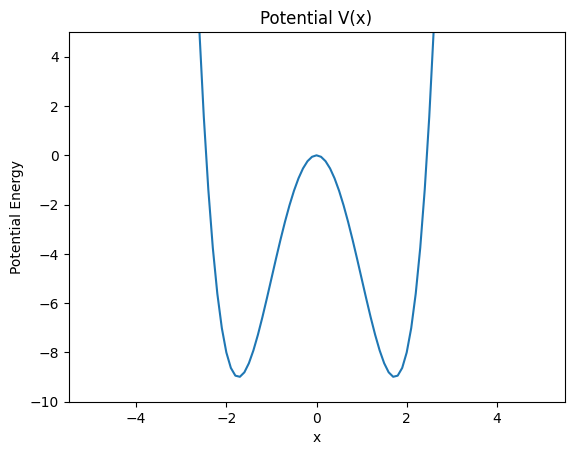

In [43]:
#Plot potential energy
Vx = getV(x)

plt.plot(x, Vx)
plt.ylim(-10, 5)
plt.title('Potential V(x)')
plt.xlabel('x')
plt.ylabel('Potential Energy')
plt.show()

Plotting


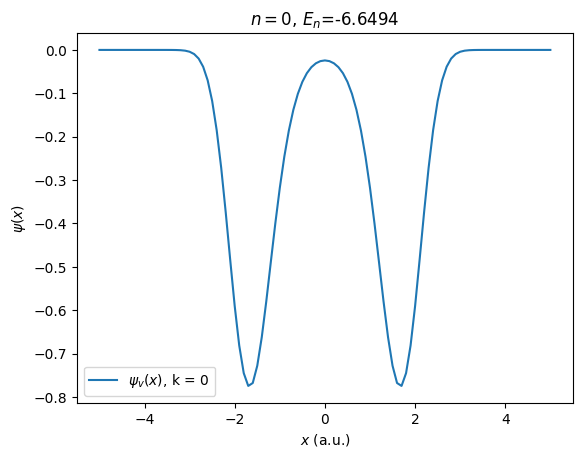

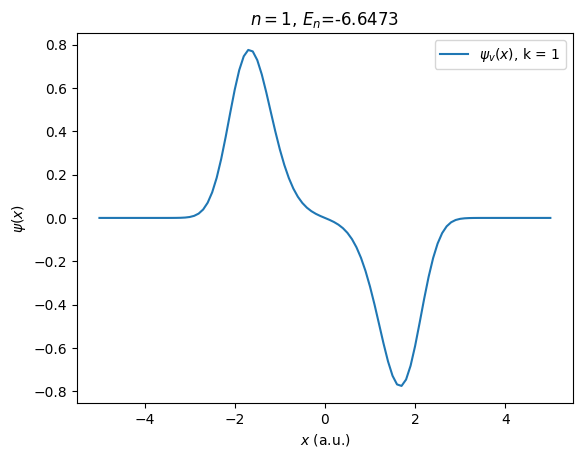

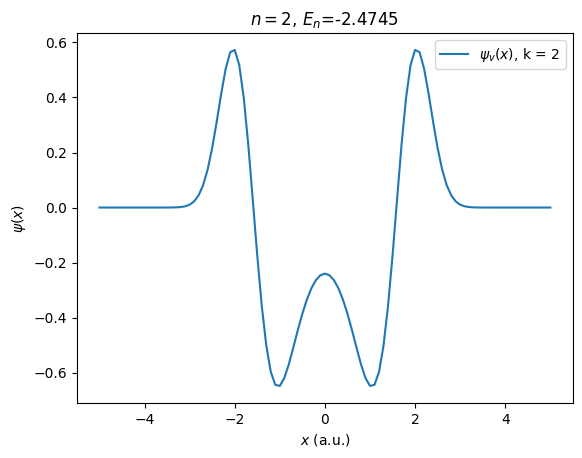

In [44]:
#Init Wavefunction (empty list with npoints elements)
psi = [None]*npoints

#Calculation of normalised Wave Functions
for k in range(0,len(w)):
	psi[k] = vs[:,k]
	integral = h*np.dot(psi[k],psi[k])
	psi[k] = psi[k]/integral**0.5

#Plot Wave functions
print("Plotting")

#v = int(input("\n Quantum Number (enter 0 for ground state):\n>"))
for v in range(0,3):
	plt.plot(x,psi[v],label=r'$\psi_v(x)$, k = ' + str(v))
	plt.title(r'$n=$'+ str(v) + r', $E_n$=' + '{:.4f}'.format(E[v]))
	plt.legend()
	plt.xlabel(r'$x$ (a.u.)')
	plt.ylabel(r'$\psi(x)$')
	plt.show()

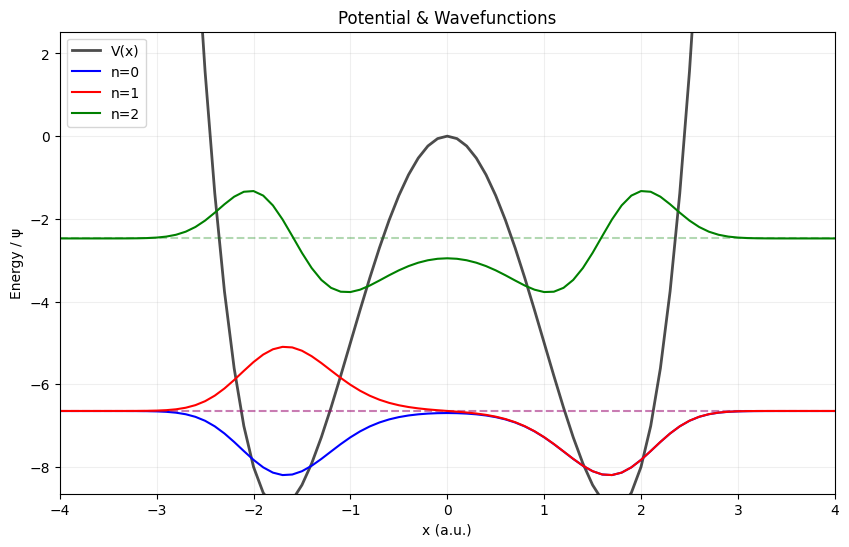

In [46]:
plt.figure(figsize=(10, 6))
colors = ['blue', 'red', 'green']

# Potential
plt.plot(x, Vx, 'k', lw=2, alpha=0.7, label='V(x)')

# Wavefunctions (ψ) offset by energy
for i, c in enumerate(colors):
    plt.axhline(E[i], color=c, ls='--', alpha=0.3)
    plt.plot(x, 2*psi[i] + E[i], color=c, label=f'n={i}')

plt.title('Potential & Wavefunctions')
plt.xlabel('x (a.u.)')
plt.ylabel('Energy / ψ')
plt.xlim(-4, 4)
plt.ylim(E[0]-2, E[2]+5)
plt.legend(loc='upper left')
plt.grid(alpha=0.2)
plt.show()

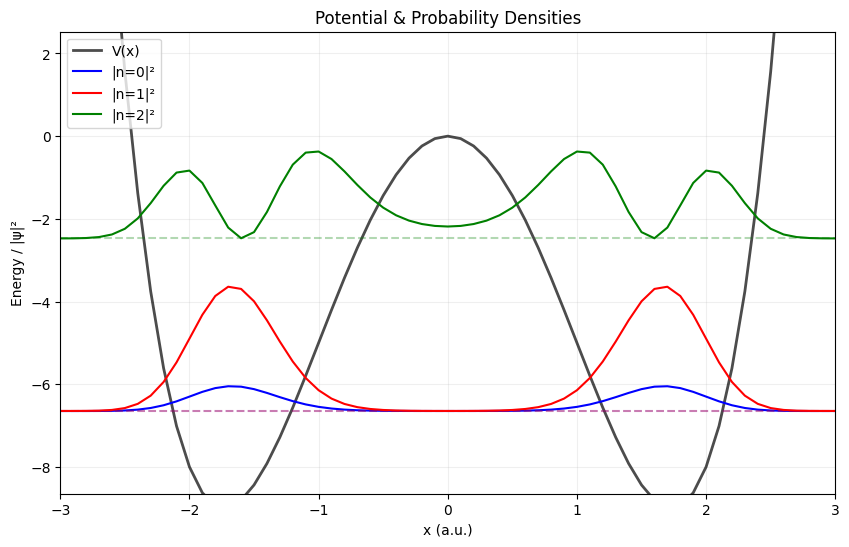

In [45]:
plt.figure(figsize=(10, 6))
colors = ['blue', 'red', 'green']

# Potential
plt.plot(x, Vx, 'k', lw=2, alpha=0.7, label='V(x)')

# Probability Densities (|ψ|²) offset by energy
for i, c in enumerate(colors):
    # Use a shorter scale (1) for n=0 to make it stand out, others stay at 5
    scale = 1 if i == 0 else 5
    plt.axhline(E[i], color=c, ls='--', alpha=0.3)
    plt.plot(x, scale*(psi[i]**2) + E[i], color=c, label=f'|n={i}|²')

plt.title('Potential & Probability Densities')
plt.xlabel('x (a.u.)')
plt.ylabel('Energy / |ψ|²')
plt.xlim(-3, 3)
plt.ylim(E[0]-2, E[2]+5)
plt.legend(loc='upper left')
plt.grid(alpha=0.2)
plt.show()